# Convolución Continua:

**Carrera:** Ingeniería Electrónica / Ingeniería en Computación \
**Institución:** Facultad de Ingeniería | UNLP \
**Docente responsable:** Germán Scillone

## Sobre este notebook

Este notebook tiene como objetivo mostrar la operación de convolución entre dos señales continuas, $x(t)$ y $h(t)$, de una manera visual e interactiva.

### Copia editable
Para modificar y trabajar a partir de este notebook se pueden generar una copia privada:
1. Ir a **Archivo → Guardar una copia en Drive**.

### Contacto
- Correo: german.scillone@ing.unlp.edu.ar





### 1. Importar Librerías

Importamos las librerías que vamos a utilizar: `numpy` para los cálculos, `matplotlib` para las gráficas y `ipywidgets` para los controles interactivos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

%matplotlib widget

### 2. Definición de las Señales

Vamos a definir algunas de las funciones de referencia que tenemos como cajones, escalones y triangulos.

In [2]:
def cajon(t):
    """
    Define una función cajón.
    Vale 1 entre '-1/2' y '1/2', y 0 en el resto.
    """
    return np.where((np.abs(t) <= 1/2), 1, 0)

def triangulo(t):
    """
    Define una función triangular.
    """
    return np.where(np.abs(t) <= 1, 1 - np.abs(t), 0)

def escalon(t):
    """
    Define una función escalón, que vale 1 para t > 0, o 0 caso contrario.
    """
    return np.where((t > 0), 1, 0)

### 3. Graficar las Señales Originales

Visualicemos las dos señales que vamos a convolucionar.

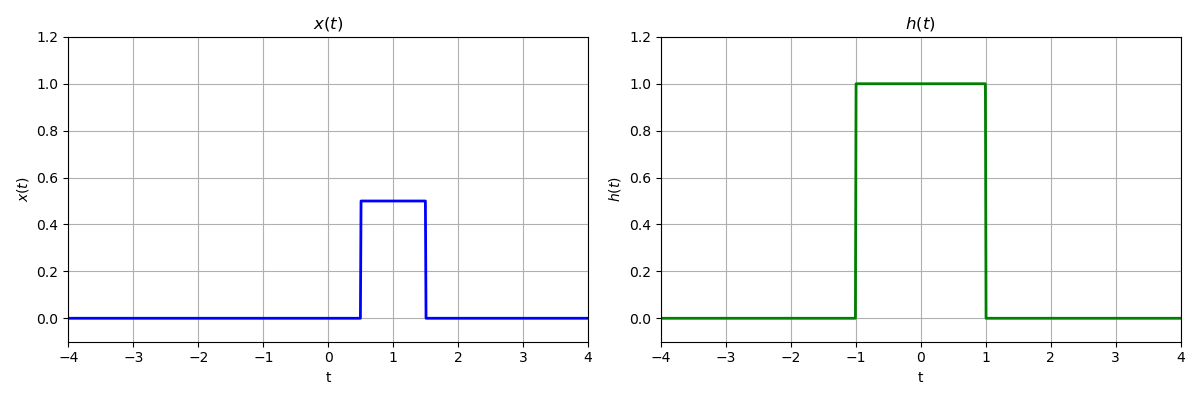

In [3]:
# Definimos un eje de tiempo común para graficar
t = np.linspace(-10, 10, 2000)

# Creamos las dos señales a convolucionar:
x_t = 0.5*cajon(t - 1)
h_t = cajon(t/2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica de x(t)
ax1.plot(t, x_t, 'b', linewidth=2)
ax1.set_title('$x(t)$')
ax1.set_xlabel('t')
ax1.set_ylabel('$x(t)$')
ax1.grid(True)
ax1.set_ylim(-0.1, 1.2)
ax1.set_xlim(-4, 4)

# Gráfica de h(t)
ax2.plot(t, h_t, 'g', linewidth=2)
ax2.set_title('$h(t)$')
ax2.set_xlabel('t')
ax2.set_ylabel('$h(t)$')
ax2.grid(True)
ax2.set_ylim(-0.1, 1.2)
ax2.set_xlim(-4, 4)

plt.tight_layout()
plt.show()

### 4. La Operación de Convolución

La convolución de dos funciones continuas, $x(t)$ y $h(t)$, se define como la integral del producto de una función con la versión **reflejada y desplazada** de la otra. El resultado es una nueva función, $y(t)$, donde la variable $t$ representa el desplazamiento aplicado a la función reflejada antes del producto.

La fórmula es:

$$ y(t) = (x * h)(t) = \int_{-\infty}^{\infty} x(\tau)\,h(t - \tau)\,d\tau $$

- **$\tau$** (tau): Variable de integración; consideramos las señales como funciones de $\tau$ durante el cálculo.  
- **$x(\tau)$**: Primera señal, que permanece fija en la operación.  
- **$h(t - \tau)$** (equivalente a **$h(-(\tau - t))$**): Segunda señal. El término $t - \tau$ implica que $h(\tau)$ se **refleja en el eje vertical** ($h(-\tau)$) y luego se **desplaza** una cantidad $t$.  
- **$t$**: Variable independiente de la salida. Para cada valor de $t$, se evalúa la integral, generando así la señal $y(t)$ punto a punto.  

En el análisis de sistemas lineales e invariantes en el tiempo (SLIT), la convolución es de sumo interés ya que permite determinar la salida ante cualquier entrada $x(t)$, al realizar la operación entre la entrada y la respuesta impulsional del sistema $h(t)$.

### 5. Visualización Interactiva

El siguiente bloque te permite variar el desplazamiento $t$ con un slider. Observa cómo cambian las tres gráficas para entender el proceso:

1.  **Gráfica 1 (Izquierda)**: Muestra la señal fija $x(\tau)$ (azul) y la señal invertida y desplazada $h(t - \tau)$ (rojo), y el valor de desplazamiento t en la barra negra vertical.
2.  **Gráfica 2 (Centro)**: Muestra el producto punto a punto de las dos señales anteriores, es decir el integrando de la convolución. El **área sombreada en rojo** representa el valor de la integral para ese instante $t$ específico. Este área es, literalmente, el valor de $y(t)$ en ese punto.
3.  **Gráfica 3 (Derecha)**: Muestra la señal de salida $y(t)$ que se va construyendo a medida que barremos el valor de $t$. El punto resalta el valor actual que se está calculando. La línea punteada de fondo muestra el resultado final de la convolución como referencia.

interactive(children=(FloatSlider(value=-3.0, description='Tiempo (t)', max=5.0, min=-3.0, step=0.05), Output(…

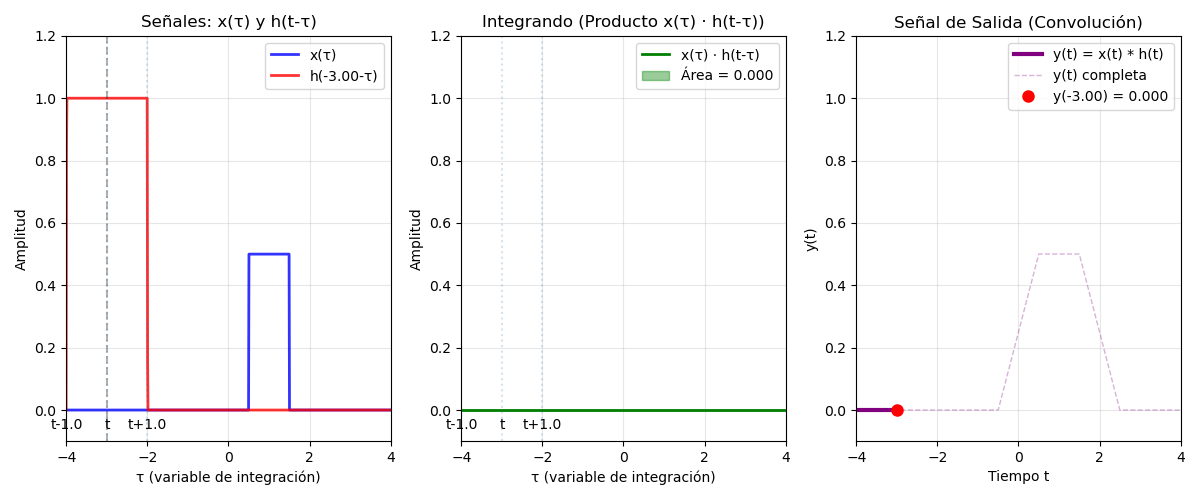

In [16]:
# Vamos a definir las figuras en función de tau
tau = t # Mismo rango que definimos antes.

# Pre-calcular la convolución completa para referencia
dt = t[1] - t[0]
y_complete = np.convolve(x_t, h_t, mode='full') * dt
t_conv = np.arange(0, len(y_complete)) * dt + t[0] + t[0]

# Creamos las figuras donde vamos a visualizar los resultados:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

def Update(t_val: float):
    """ 
    Función para actualizar las gráficas en función de un valor de t_val dado.
    """
    # Limpiamos las gráficas
    ax1.clear()
    ax2.clear()
    ax3.clear()

    # Re-evaluamos las función reflejada y desplazada t_val.
    h_rd_t = np.interp(t_val - tau, tau, h_t, left=0.0, right=0.0)

    # SUBPLOT 1: Señales x(τ) y h(t-τ) superpuestas ===
    ax1.plot(tau, x_t, 'b-', linewidth=2, label='x(τ)', alpha=0.8)
    ax1.plot(tau, h_rd_t, 'r-', linewidth=2, label=f'h({t_val:.2f}-τ)', alpha=0.8)
    ax1.set_xlabel('τ (variable de integración)')
    ax1.set_ylabel('Amplitud')
    ax1.set_title('Señales: x(τ) y h(t-τ)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_ylim(-0.1, 1.2)
    ax1.set_xlim(-4, 4)

    # Linea con el valor de t_val:
    ax1.axvline(x=t_val, color='black', linestyle='--', alpha=0.3, label=f't = {t_val:.2f}')


    # SUBPLOT 2: Integrando: producto x(τ) · h(t-τ) ===
    integrando = x_t * h_rd_t
    ax2.plot(tau, integrando, 'g-', linewidth=2, label='x(τ) · h(t-τ)')
    ax2.fill_between(tau, 0, integrando, alpha=0.4, color='green', label=f'Área = {np.trapezoid(integrando, tau):.3f}')

    ax2.set_xlabel('τ (variable de integración)')
    ax2.set_ylabel('Amplitud')
    ax2.set_title('Integrando (Producto x(τ) · h(t-τ))')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_ylim(-0.1, 1.2)
    ax2.set_xlim(-4, 4)

    # === SUBPLOT 3: Convolución y(t) ===
    # Mostrar solo hasta el tiempo actual
    t_indices = t_conv <= t_val

    ax3.plot(t_conv[t_indices], y_complete[t_indices], 'purple', linewidth=3, label='y(t) = x(t) * h(t)')
    ax3.plot(t_conv, y_complete, 'purple', linewidth=1, alpha=0.3, linestyle='--', label='y(t) completa')

    # Marcar el punto actual
    if t_val >= t_conv[0] and t_val <= t_conv[-1]:
        idx_current = np.argmin(np.abs(t_conv - t_val))
        if idx_current < len(y_complete):
            ax3.plot(t_val, y_complete[idx_current], 'ro', markersize=8, label=f'y({t_val:.2f}) = {y_complete[idx_current]:.3f}')

    ax3.set_xlabel('Tiempo t')
    ax3.set_ylabel('y(t)')
    ax3.set_title('Señal de Salida (Convolución)')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    ax3.set_ylim(-0.1, 1.2)
    ax3.set_xlim(-4, 4)

    # Etiquetas auxiliares de tiempo: (t-1), (t-2), (t+1)
    for delta in [0, -1, +1]:
        ax1.axvline(x=t_val+delta, linestyle=':', alpha=0.2, label='_nolegend_')
        ax1.text(t_val+delta, -0.07, 't' if delta == 0 else f't{delta:+0.1f}', ha='center', va='bottom', fontsize=10, rotation=0)
        ax2.axvline(x=t_val+delta, linestyle=':', alpha=0.2, label='_nolegend_')
        ax2.text(t_val+delta, -0.07, 't' if delta == 0 else f't{delta:+0.1f}', ha='center', va='bottom', fontsize=10, rotation=0)

    # Dibujamos los gráficos
    plt.tight_layout()
    fig.canvas.draw_idle()

# Iteración incial.
Update(-3)

# Slider para el tiempo.
slider = FloatSlider(min=-3.0, max=5.0, step=0.05, value=-3, description='Tiempo (t)', continuous_update=True)
interact(Update, t_val=slider);
